# Badminton Scoring System Simulation

This was done to examine some of the claims made by the BWF regarding their proposal to change from a 3x21 to a 3x15 scoring system.

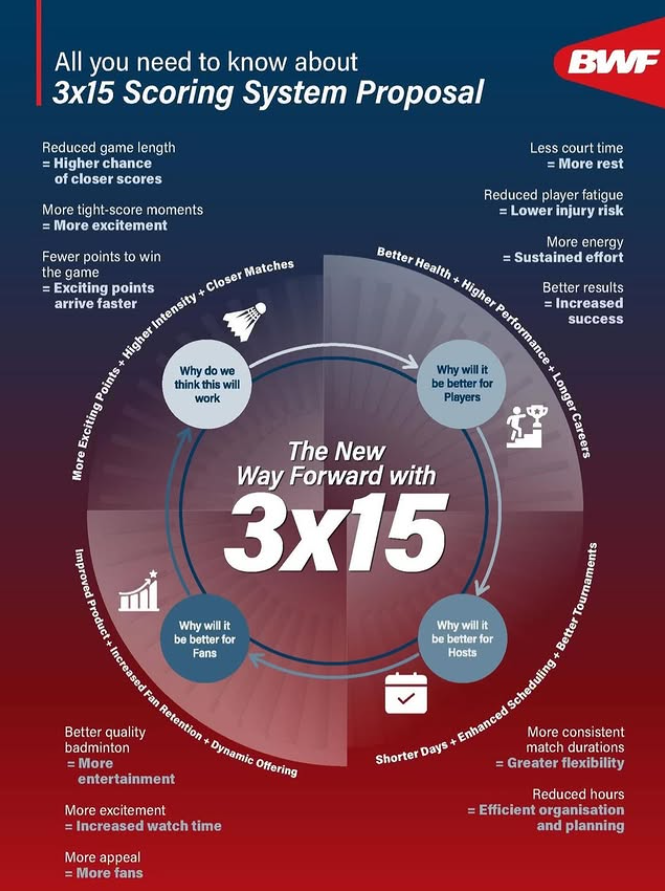

Although not all these claims can be tested, we must remember that **"correlation is not causation"**.

A less technical version of this notebook can be found on my Substack:
https://towbsss.substack.com/p/who-really-wins-from-the-3-x-15-scoring

### Part 1: Core Simulation Mechanics

To test the BWF's claims, we need to simulate badminton matches. To ensure a statistically fair comparison, we are using a **paired sample** approach. Instead of simulating two completely different matches, we generate a single sequence of random rallies and evaluate that *exact same sequence* under both the 21-point rules and the 15-point rules.

**Our Assumptions:**
* **Independent Rallies:** Every point is an independent event. We are assuming the "hot hand" or momentum effect is statistically insignificant.
* **Fixed Probability:** Player A has a fixed, continuous probability (`p_a`) of winning any given rally.

**The Functions:**
1. **`generate_point_sequence(p_a, max_points)`**: Flips a weighted coin to generate a long sequence of rally winners (e.g., `['A', 'A', 'B', ...]`). We generate 100 points, which is mathematically enough to guarantee any single game finishes under either rule set.
2. **`evaluate_game(sequence, target, cap)`**: Acts as the umpire. It reads the point sequence left-to-right and calculates the score. The game ends when a player hits the `target` score (and leads by at least 2 points), or when a player hits the hard `cap` (e.g., 30 or 21).

In [ ]:
import random
import pandas as pd

# 1. Function to generate a long sequence of rallies
def generate_point_sequence(p_a, max_points=100):
    """
    Generates a sequence of points won by 'A' or 'B'.
    p_a: Probability that Player A wins any given rally (e.g., 0.55)
    """
    return ['A' if random.random() < p_a else 'B' for _ in range(max_points)]

# 2. Function to evaluate a game based on specific rules
def evaluate_game(sequence, target=21, cap=30):
    """
    Reads a sequence of points and stops when the rule conditions are met.
    Returns: Winner ('A' or 'B'), Score A, Score B, Total Rallies played
    """
    score_a = 0
    score_b = 0
    rallies = 0

    for point in sequence:
        if point == 'A':
            score_a += 1
        else:
            score_b += 1

        rallies += 1

        # Check if someone has reached the target score
        if score_a >= target or score_b >= target:
            # Check for win by 2, OR if the hard cap is reached
            if abs(score_a - score_b) >= 2 or score_a == cap or score_b == cap:
                winner = 'A' if score_a > score_b else 'B'
                return winner, score_a, score_b, rallies

In [ ]:
# Let's test it out with a single game sequence!
# Assume Player A is slightly better (55% chance to win a rally)
test_sequence = generate_point_sequence(p_a=0.55)

# Evaluate under current 21-point rules (capped at 30)
winner_21, score_a_21, score_b_21, rallies_21 = evaluate_game(test_sequence, target=21, cap=30)

# Evaluate under proposed 15-point rules (capped at 21)
winner_15, score_a_15, score_b_15, rallies_15 = evaluate_game(test_sequence, target=15, cap=21)

print("--- Single Game Test ---")
print(f"21-Point Format: {winner_21} wins {score_a_21}-{score_b_21} (Took {rallies_21} rallies)")
print(f"15-Point Format: {winner_15} wins {score_a_15}-{score_b_15} (Took {rallies_15} rallies)")

--- Single Game Test ---
21-Point Format: A wins 21-12 (Took 33 rallies)
15-Point Format: A wins 15-5 (Took 20 rallies)


### Part 2: Simulating a Full Match & Catching Anomalies

In set-based sports like badminton, games are wiped clean once they are won. This creates a fascinating statistical anomaly: **a player can win the match while scoring fewer total points than their opponent** (e.g., winning two close games but losing one in a massive blowout).

To test if the proposed 3x15 system changes how often this anomaly occurs, we need to simulate a full Best-of-3 match.

**How we handle the Match Simulation:**
1. **Three Sequences:** To maintain our "paired sample" approach (ensuring the exact same luck across both scoring formats), we generate three separate sequences of 100 points *before* the match starts—one for Game 1, Game 2, and a potential Game 3.
2. **Best-of-Three Logic:** The `simulate_match` function acts as the tournament director. It feeds the pre-generated sequences into our `evaluate_game` umpire one by one. It stops the match early if a player wins the first two games.
3. **Tracking Score Lines:**
To make our data more readable and verifiable, the `simulate_match` function also captures the final score of each game played (e.g., `21-19, 15-21, 23-21`). It appends each game's `score_a` and `score_b` to a `score_lines` list as they finish, returning it alongside the rest of our match data.
4. **Tracking the Anomaly:** As the games are played, we keep a running tally of `total_points_A` and `total_points_B`. At the end of the match, we check if the overall match winner actually scored fewer total points than the loser, flagging it as `True` if they did.

In [ ]:
# 3. Function to simulate a full Best-of-3 Match (Updated with Score Lines)
def simulate_match(sequences, target=21, cap=30):
    """
    Simulates a match using 3 pre-generated game sequences.
    Returns a dictionary of match statistics, including individual game scores.
    """
    games_won_A = 0
    games_won_B = 0
    total_points_A = 0
    total_points_B = 0
    total_rallies = 0

    # NEW: A list to hold the formatted score strings
    score_lines = []

    # Iterate through our 3 game sequences
    for i in range(3):
        # Stop playing if someone has already won 2 games
        if games_won_A == 2 or games_won_B == 2:
            break

        # Grab the sequence for the current game
        current_game_sequence = sequences[i]

        # Umpire the game using our previous function
        winner, score_a, score_b, rallies = evaluate_game(current_game_sequence, target, cap)

        # NEW: Format the score and add it to our list
        score_lines.append(f"{score_a}-{score_b}")

        # Tally the game wins
        if winner == 'A':
            games_won_A += 1
        else:
            games_won_B += 1

        # Tally the total points and rallies
        total_points_A += score_a
        total_points_B += score_b
        total_rallies += rallies

    # Determine the overall match winner
    match_winner = 'A' if games_won_A == 2 else 'B'

    # Check for the anomaly: Did the winner score fewer total points?
    won_with_fewer_points = False
    if match_winner == 'A' and total_points_A < total_points_B:
        won_with_fewer_points = True
    elif match_winner == 'B' and total_points_B < total_points_A:
        won_with_fewer_points = True

    return {
        'winner': match_winner,
        'games_A': games_won_A,
        'games_B': games_won_B,
        'points_A': total_points_A,
        'points_B': total_points_B,
        'total_rallies': total_rallies,
        'won_with_fewer_points': won_with_fewer_points,
        'score_lines': score_lines
    }


In [ ]:
# --- Let's test it and print the nice score lines! ---

# Generate 3 independent sequences
p_a = 0.52
match_sequences = [
    generate_point_sequence(p_a),
    generate_point_sequence(p_a),
    generate_point_sequence(p_a)
]

# Run the sequences through both rule sets
match_21 = simulate_match(match_sequences, target=21, cap=30)
match_15 = simulate_match(match_sequences, target=15, cap=21)

print("--- Single Match Test ---")
print("21-Point Format:")

print(f"Winner: {match_21['winner']} | Scores: {', '.join(match_21['score_lines'])}")
print(f"Total Points: A={match_21['points_A']}, B={match_21['points_B']}")
print(f"Won with fewer total points? {match_21['won_with_fewer_points']}")
print(f"Total Rallies Played: {match_21['total_rallies']}\n")

print("15-Point Format:")
print(f"Winner: {match_15['winner']} | Scores: {', '.join(match_15['score_lines'])}")
print(f"Total Points: A={match_15['points_A']}, B={match_15['points_B']}")
print(f"Won with fewer total points? {match_15['won_with_fewer_points']}")
print(f"Total Rallies Played: {match_15['total_rallies']}")

--- Single Match Test ---
21-Point Format:
Winner: A | Scores: 21-17, 17-21, 23-21
Total Points: A=61, B=59
Won with fewer total points? False
Total Rallies Played: 120

15-Point Format:
Winner: B | Scores: 15-8, 15-17, 11-15
Total Points: A=41, B=40
Won with fewer total points? True
Total Rallies Played: 81


### Part 3: The Monte Carlo Simulation

To test the BWF's claims comprehensively, we will run thousands of simulated matches. By varying the probability of Player A winning a rally ($p$), we can also see how skill disparities affect match dynamics (e.g., do shorter games result in more upsets?).

**What we are testing:**
1. **Court Time:** Average total rallies played (3x15 vs. 3x21).
2. **Match Consistency:** The spread (variance) of total rallies played.
3. **Closer Scores:** The average point differential at the end of each game.
4. **Upset Probability:** How often the statistically weaker player wins the match.

**Methodology:**
We will simulate matches across a range of skill disparities (from $p = 0.50$, perfectly equal, to $p = 0.70$, highly dominant). We will run 1,000 matches per probability level, running the exact same rally sequences through both scoring systems, and compile the results into a Pandas DataFrame for visualization using Seaborn.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Helper function to calculate average point differential from our score strings
def get_avg_diff(score_lines):
    diffs = [abs(int(s.split('-')[0]) - int(s.split('-')[1])) for s in score_lines]
    return np.mean(diffs)

def run_monte_carlo(n_iterations=1000, p_values=[0.50, 0.55, 0.60, 0.65, 0.70]):
    """
    Runs a Monte Carlo simulation across different probabilities.
    Returns a Pandas DataFrame of the results.
    """
    print(f"Starting simulation: {n_iterations} matches per probability level...")
    results = []

    for p in p_values:
        for _ in range(n_iterations):
            # Generate 3 shared sequences for the match
            seqs = [generate_point_sequence(p, max_points=120) for _ in range(3)]

            # Simulate both formats
            match_21 = simulate_match(seqs, target=21, cap=30)
            match_15 = simulate_match(seqs, target=15, cap=21)

            # Record 21-point format results
            results.append({
                'Probability (p_A)': p,
                'Format': '3x21 (Current)',
                'Match_Winner': match_21['winner'],
                'Total_Rallies': match_21['total_rallies'],
                'Avg_Point_Diff': get_avg_diff(match_21['score_lines']),
                'Won_Fewer_Points': match_21['won_with_fewer_points']
            })

            # Record 15-point format results
            results.append({
                'Probability (p_A)': p,
                'Format': '3x15 (Proposed)',
                'Match_Winner': match_15['winner'],
                'Total_Rallies': match_15['total_rallies'],
                'Avg_Point_Diff': get_avg_diff(match_15['score_lines']),
                'Won_Fewer_Points': match_15['won_with_fewer_points']
            })

    print("Simulation complete!")
    return pd.DataFrame(results)


Starting simulation: 1000000 matches per probability level...
Simulation complete!


/tmp/ipykernel_13327/3603426374.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  upset_df = df_results.groupby(['Probability (p_A)', 'Format']).apply(


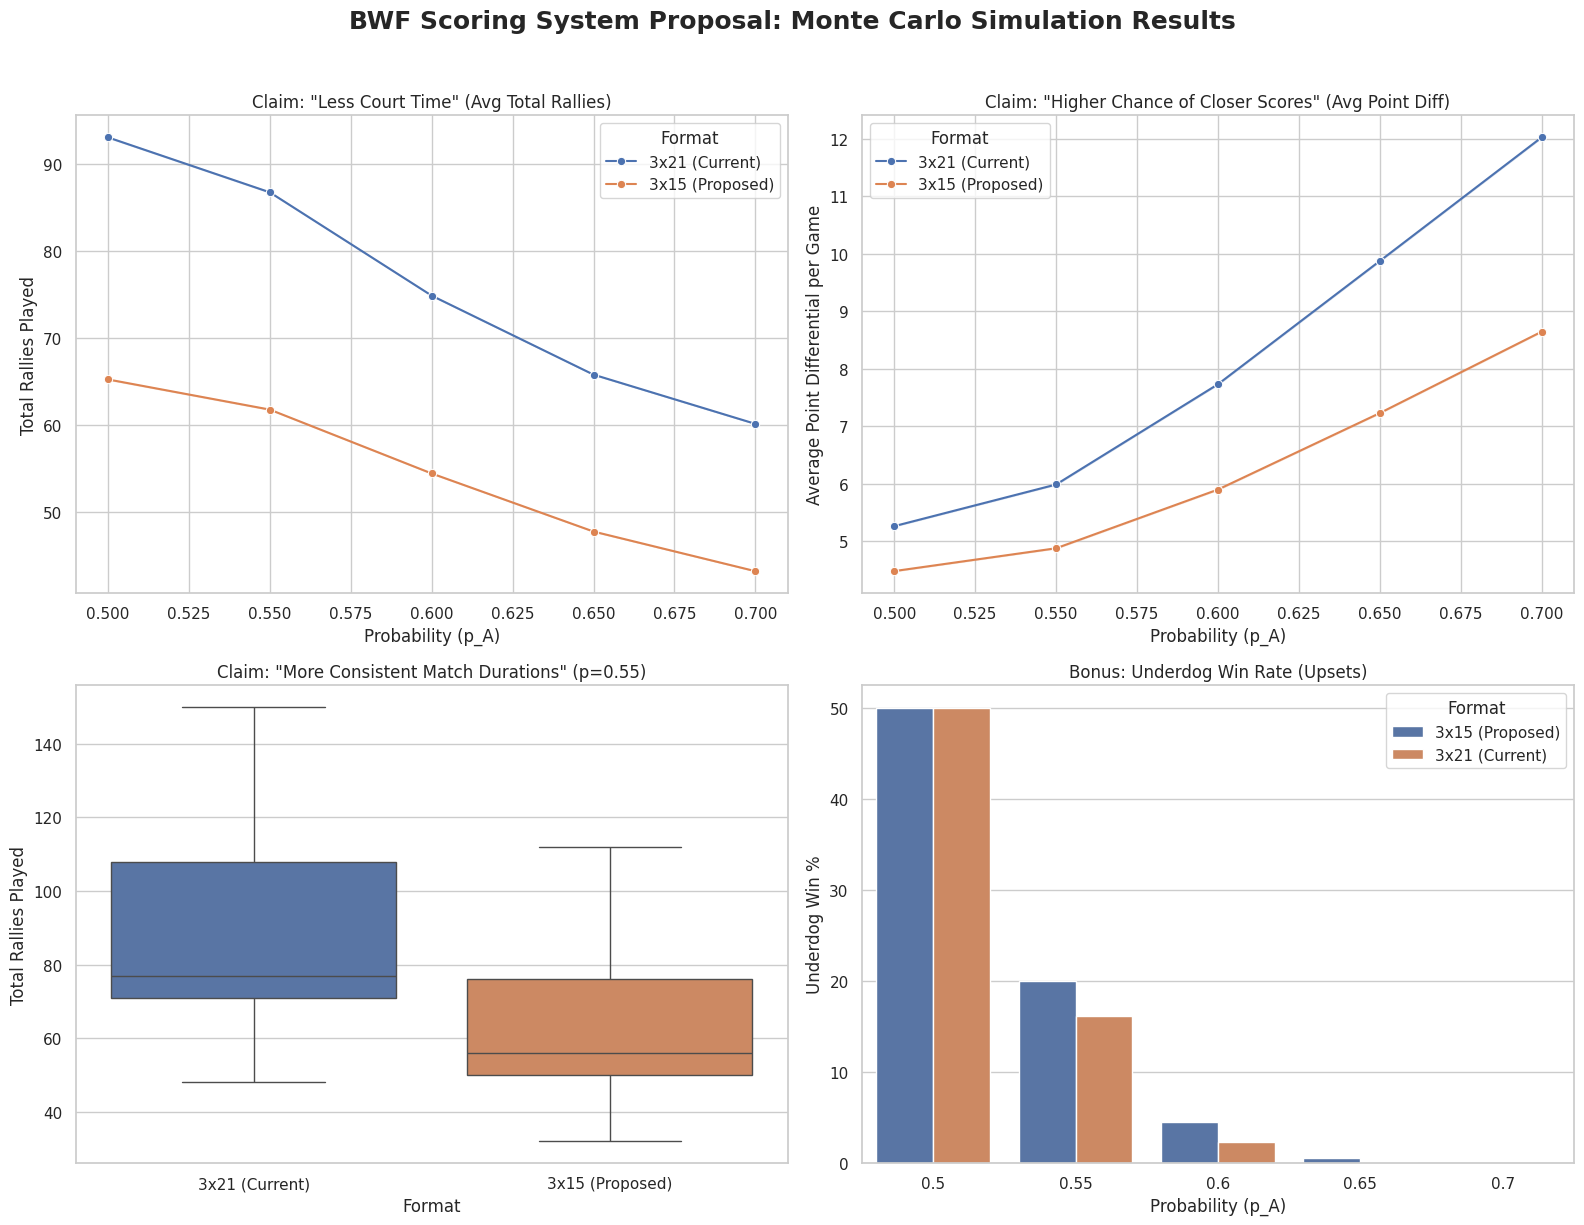

In [ ]:
# 1. Run the Simulation
df_results = run_monte_carlo(n_iterations=1000000) # THIS TAKES TIME!

# 2. Set up visualization styling
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('BWF Scoring System Proposal: Monte Carlo Simulation Results', fontsize=18, fontweight='bold', y=1.02)

# --- Chart 1: Court Time (Total Rallies) ---
sns.lineplot(data=df_results, x='Probability (p_A)', y='Total_Rallies', hue='Format', ax=axes[0, 0], marker='o')
axes[0, 0].set_title('Claim: "Less Court Time" (Avg Total Rallies)')
axes[0, 0].set_ylabel('Total Rallies Played')

# --- Chart 2: Closer Scores (Point Differential) ---
sns.lineplot(data=df_results, x='Probability (p_A)', y='Avg_Point_Diff', hue='Format', ax=axes[0, 1], marker='o')
axes[0, 1].set_title('Claim: "Higher Chance of Closer Scores" (Avg Point Diff)')
axes[0, 1].set_ylabel('Average Point Differential per Game')

# --- Chart 3: Consistent Match Durations (Spread of Rallies) ---
# We filter to p=0.55 to look at the variance/spread of a typical competitive match
df_competitive = df_results[df_results['Probability (p_A)'] == 0.55]
sns.boxplot(data=df_competitive, x='Format', y='Total_Rallies', ax=axes[1, 0], hue="Format", legend=False)
axes[1, 0].set_title('Claim: "More Consistent Match Durations" (p=0.55)')
axes[1, 0].set_ylabel('Total Rallies Played')

# --- Chart 4: Upset Probability ---
# Select the 'Match_Winner' column specifically before applying our logic
upset_df = df_results.groupby(['Probability (p_A)', 'Format'])['Match_Winner'].apply(
    lambda x: (x == 'B').mean() * 100
).reset_index(name='Upset_Percentage')

sns.barplot(data=upset_df, x='Probability (p_A)', y='Upset_Percentage', hue='Format', ax=axes[1, 1])
axes[1, 1].set_title('Bonus: Underdog Win Rate (Upsets)')
axes[1, 1].set_ylabel('Underdog Win %')

sns.barplot(data=upset_df, x='Probability (p_A)', y='Upset_Percentage', hue='Format', ax=axes[1, 1])
axes[1, 1].set_title('Bonus: Underdog Win Rate (Upsets)')
axes[1, 1].set_ylabel('Underdog Win %')

plt.tight_layout()
plt.show()

### Part 4: The Player's Burden (Experience ROI Analysis)

While the BWF claims shorter matches benefit tournament logistics, we must examine the financial and developmental impact on the athletes.

For a developing player from an under-funded nation, international tournaments are a massive financial investment. Their goal is to gain high-level court experience. If we assume a fixed cost of **$1,000 USD** to travel and enter a tournament, and an average active rally time of **7 seconds** (excluding dead time), we can calculate the true "Cost per Active Minute" of experience.

By shortening the matches, the 3x15 system artificially inflates the cost of experience, heavily penalizing athletes who are eliminated in the early rounds (Round of 32 or Round of 16).

--- Player Experience Value (ROI) ---
Assumptions: $1000 Fixed Cost, 7s Active Play per Rally

Format                3x15 (Proposed)  3x21 (Current)
Tournament Exit                                      
R32 (1 Match)                  138.67           98.77
R16 (2 Matches)                 69.33           49.38
Quarters (3 Matches)            46.22           32.92
Semis (4 Matches)               34.67           24.69
Finals (5 Matches)              27.73           19.75


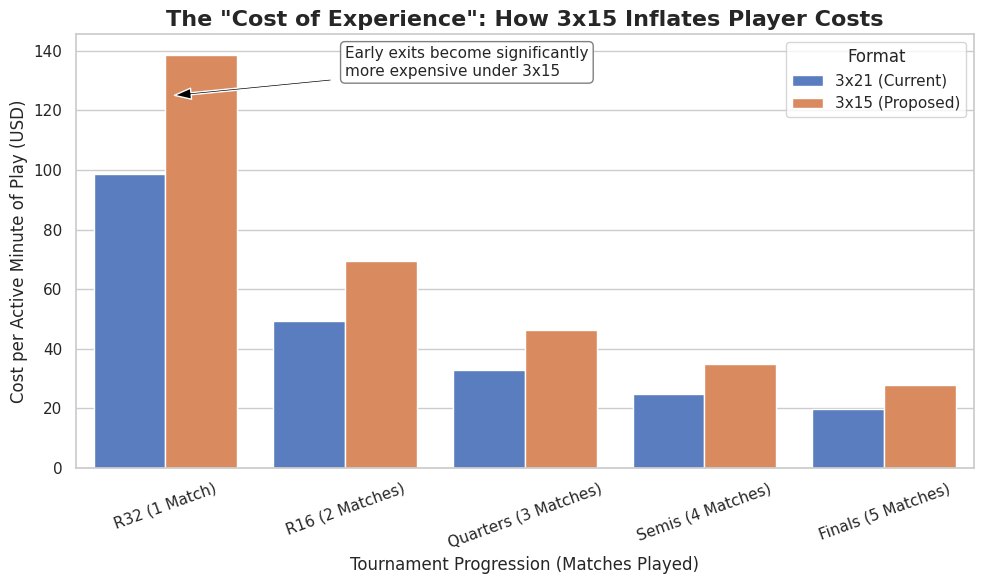

In [ ]:
# 1. Define our new Player-focused variables
active_rally_sec = 7.0
tournament_cost = 1000.0 # Fixed travel/entry cost in USD

# Ensure we have the average rallies from our p=0.55 simulation (Standard competitive match)
df_comp = df_results[df_results['Probability (p_A)'] == 0.55]
avg_rallies_21 = df_comp[df_comp['Format'] == '3x21 (Current)']['Total_Rallies'].mean()
avg_rallies_15 = df_comp[df_comp['Format'] == '3x15 (Proposed)']['Total_Rallies'].mean()

# Calculate pure active time per match (in minutes)
active_mins_21 = (avg_rallies_21 * active_rally_sec) / 60.0
active_mins_15 = (avg_rallies_15 * active_rally_sec) / 60.0

# 2. Simulate a tournament run (1 to 5 matches)
player_roi_data = []
rounds = ['R32 (1 Match)', 'R16 (2 Matches)', 'Quarters (3 Matches)', 'Semis (4 Matches)', 'Finals (5 Matches)']

for i, round_name in enumerate(rounds):
    matches_played = i + 1

    # Total active minutes played up to this round
    total_time_21 = active_mins_21 * matches_played
    total_time_15 = active_mins_15 * matches_played

    # Cost per minute of experience
    cost_per_min_21 = tournament_cost / total_time_21
    cost_per_min_15 = tournament_cost / total_time_15

    player_roi_data.append({
        'Tournament Exit': round_name,
        'Format': '3x21 (Current)',
        'Total Active Mins': total_time_21,
        'Cost per Minute ($)': cost_per_min_21
    })

    player_roi_data.append({
        'Tournament Exit': round_name,
        'Format': '3x15 (Proposed)',
        'Total Active Mins': total_time_15,
        'Cost per Minute ($)': cost_per_min_15
    })

df_roi = pd.DataFrame(player_roi_data)

# 3. Display the DataFrame cleanly
print("--- Player Experience Value (ROI) ---")
print(f"Assumptions: $1000 Fixed Cost, 7s Active Play per Rally\n")
# We pivot the table so it's easy to read in the console
df_pivot = df_roi.pivot(index='Tournament Exit', columns='Format', values='Cost per Minute ($)')
# Reorder index to match tournament progression
df_pivot = df_pivot.reindex(rounds)
print(df_pivot.round(2).to_string())

# 4. Visualize the Financial Impact
plt.figure(figsize=(10, 6))
sns.barplot(data=df_roi, x='Tournament Exit', y='Cost per Minute ($)', hue='Format', palette='muted')

plt.title('The "Cost of Experience": How 3x15 Inflates Player Costs', fontsize=16, fontweight='bold')
plt.ylabel('Cost per Active Minute of Play (USD)')
plt.xlabel('Tournament Progression (Matches Played)')
plt.xticks(rotation=20)

# Add a text annotation to highlight the first-round penalty
plt.annotate(
    'Early exits become significantly\nmore expensive under 3x15',
    xy=(0, df_roi['Cost per Minute ($)'].max() * 0.9),
    xytext=(1, df_roi['Cost per Minute ($)'].max() * 0.95),
    arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1)
)

plt.tight_layout()
plt.show()